🔁 Pred view refresh at 2025-10-31 19:21:00
Querying last 120 minutes from table 'bch_usdt_1m_logreg_base' since 2025-10-31 17:21:00


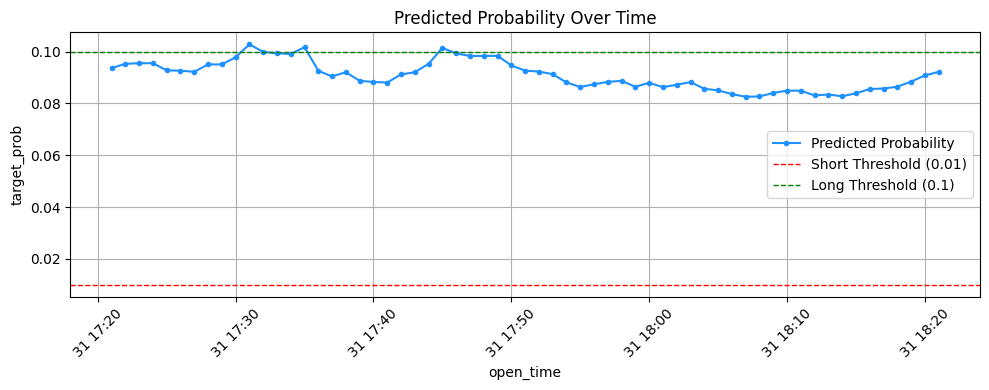

In [ ]:
# =============================================================================
# Minimal main loop (UTC+0) - full sync chain with persistent output
# BASE → DEV → LOGREG → PRED VIEW
# - Az output minden iteráció elején törlődik
# - Csak az aktuális ciklus eredményei látszanak
# =============================================================================
from typing import Optional
import time
import sqlite3
import pandas as pd
from datetime import timedelta
import utils as utils

# Jupyter notebook output clearing
from IPython.display import clear_output

# Local imports
from database_codes.bch_usdt_1m             import sync_bchusdt_1m
from database_codes.bch_usdt_1m_dev         import sync_bchusdt_1m_dev
from database_codes.bch_usdt_1m_logreg_base import sync_bchusdt_1m_logreg_base
from database_codes.pred_view               import run_pred_view

# =============================================================================
# CONFIG
# =============================================================================
POLL_SECONDS = 10
SEPARATOR = "-" * 60


# =============================================================================
# Helper: get max value from a table column
# =============================================================================
def _sql_max(conn: sqlite3.Connection, table: str, column: str) -> Optional[object]:
	cur = conn.cursor()
	cur.execute(f'SELECT MAX("{column}") FROM "{table}"')
	row = cur.fetchone()
	return row[0] if row and row[0] is not None else None


# =============================================================================
# MAIN LOOP
# =============================================================================
def main_loop():
	cfg = utils._load_config()

	db_cfg   = cfg.get("database", {})
	dev_cfg  = db_cfg.get("dev_data", {})
	model_cfg = cfg.get("model", {})

	DB_PATH       = db_cfg.get("db_path")
	BASE_TABLE    = dev_cfg.get("table_name")
	DEV_TABLE     = dev_cfg.get("table_name_dev")
	LOGREG_TABLE  = model_cfg.get("logreg_base_table")

	print("🟢 Starting main loop (press Stop or Ctrl+C to exit)\n")
	print(SEPARATOR)

	cycle = 1

	while True:
		# -------------------------------------------------------------------------
		# CLEAR OUTPUT - Minden iteráció elején töröljük az előző outputot
		# -------------------------------------------------------------------------
		if cycle > 1:  # Az első ciklus után kezdjük a törlést
			clear_output(wait=True)
		
		with sqlite3.connect(DB_PATH) as conn:
			base_max_time    = _sql_max(conn, BASE_TABLE, "open_time")
			base_max_time_ms = _sql_max(conn, BASE_TABLE, "open_time_ms")
			dev_max_time     = _sql_max(conn, DEV_TABLE, "open_time")
			logreg_max_time  = _sql_max(conn, LOGREG_TABLE, "open_time")

		base_max_display   = str(base_max_time)[:24]   if base_max_time else "<no data>"
		dev_max_display    = str(dev_max_time)[:24]    if dev_max_time  else "<no data>"
		logreg_max_display = str(logreg_max_time)[:24] if logreg_max_time else "<no data>"

		# -------------------------------------------------------------------------
		# START OF CYCLE
		# -------------------------------------------------------------------------
		print(SEPARATOR)
		print(f"🔁 CYCLE #{cycle} started at {utils.now_utc_str()}")
		print(SEPARATOR)

		# -------------------------------------------------------------------------
		# BASE SECTION
		# -------------------------------------------------------------------------
		print("\n" + SEPARATOR)
		print("BASE SECTION ↓")
		print(f"Base table: {BASE_TABLE}")
		print(f"Base max open_time: {base_max_display}")
		print("Starting base sync...")

		if base_max_time_ms is not None:
			start_ms = int(base_max_time_ms) + 1000
		else:
			start_ms = utils.now_utc_ms()

		sync_bchusdt_1m(start_ms)

		# -------------------------------------------------------------------------
		# DEV SECTION
		# -------------------------------------------------------------------------
		print("\n" + SEPARATOR)
		print("DEV SECTION ↓")
		print(f"Dev table: {DEV_TABLE}")
		print(f"Dev max open_time: {dev_max_display}")

		if dev_max_time is not None:
			open_time_from = (pd.to_datetime(dev_max_time) + timedelta(minutes=1)).strftime('%Y-%m-%d %H:%M:%S')
			print(f"Starting dev sync from {open_time_from}")
			sync_bchusdt_1m_dev(open_time_from)
		else:
			print("No dev data found. Skipping this cycle.")

		# -------------------------------------------------------------------------
		# LOGREG SECTION
		# -------------------------------------------------------------------------
		print("\n" + SEPARATOR)
		print("LOGREG SECTION ↓")
		print(f"Logreg table: {LOGREG_TABLE}")
		print(f"Logreg max open_time: {logreg_max_display}")

		if logreg_max_time is not None:
			open_time_from = (pd.to_datetime(logreg_max_time) + timedelta(minutes=1)).strftime('%Y-%m-%d %H:%M:%S')
			print(f"Starting logreg sync from {open_time_from}")
			sync_bchusdt_1m_logreg_base(open_time_from)
		else:
			print("No logreg data found. Skipping this cycle.")

		# -------------------------------------------------------------------------
		# PRED VIEW SECTION
		# -------------------------------------------------------------------------
		print("\n" + SEPARATOR)
		print("PRED VIEW SECTION ↓")
		print(f"Launching prediction viewer (2h window)...\n")
		run_pred_view()

		# -------------------------------------------------------------------------
		# END OF CYCLE
		# -------------------------------------------------------------------------
		print("\n" + SEPARATOR)
		print(f"✅ Cycle #{cycle} complete at {utils.now_utc_str()}. Sleeping {POLL_SECONDS} seconds...")
		print(SEPARATOR)

		cycle += 1
		time.sleep(POLL_SECONDS)


# =============================================================================
# Entrypoint
# =============================================================================
if __name__ == "__main__":
	main_loop()